This notebook creates a neuron, activates it via sigmoid activation and then trains it through Stochastic Gradient Descent. 

In [1]:
# import dependencies
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x_data = np.array([0.5, 1.25, 0.6, 0.9, 0.4, 1.3, 1.6, 0.2, 1.7, 1.05, 0.7, 1.1, 1.1, 1.4, 1.8, 1.95])
y_data = np.array([0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1])

### Utilities

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_param(x, w, b):
    return 1 / (1 + np.exp(-(w*x + b)))

def binary_cross_entropy(y, A):
    return - np.mean(
        y * np.log(A) + 
        (1 - y) * np.log(1 - A)
    )

In [4]:
def logreg_classifier(X, y, lr, W, b, epochs):

    loss_tracker = []

    for epoch in range(epochs):
    
        A = sigmoid_param(X, W, b)
    
        loss = binary_cross_entropy(y, A)

        loss_tracker.append(loss)
    
        dW = np.mean((A - y) * X)
        db = np.mean(A - y)

        W -= lr * dW
        b -= lr * db

    return W, b, loss_tracker

### Build

In [5]:
# starting conditions
weight = 1
bias = 1
learning_rate = 0.1
epoch = 1000

weight, bias, loss_data = logreg_classifier(x_data, y_data, learning_rate, weight, bias, epoch)

### Visualisation

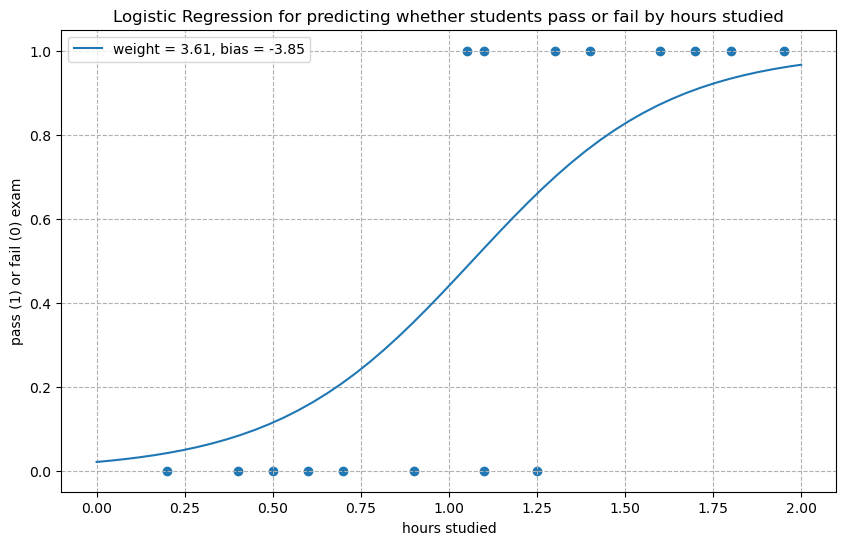

In [6]:
# visualising the logistic regression
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data)

x_values = np.linspace(0, 2, 50)

plt.plot(x_values, sigmoid_param(x_values, weight, bias), label=f"weight = {weight:.2f}, bias = {bias:.2f}")

plt.title("Logistic Regression for predicting whether students pass or fail by hours studied")
plt.ylabel("pass (1) or fail (0) exam")
plt.xlabel("hours studied")
plt.grid(ls="--")
plt.legend()
plt.show()

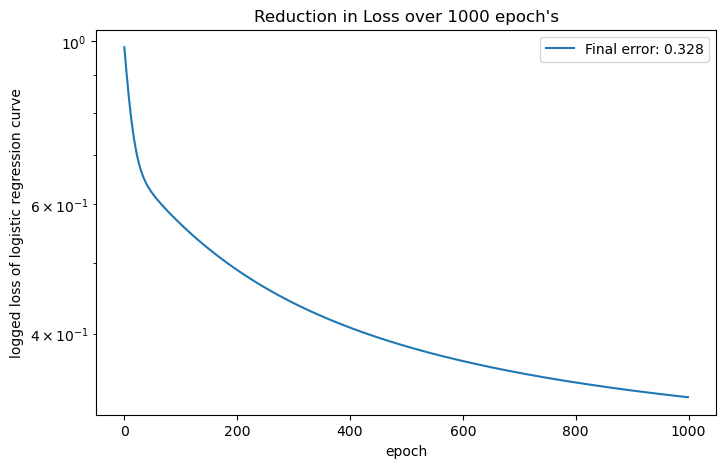

In [7]:
plt.figure(figsize=(8,5))
plt.semilogy(loss_data, label=f"Final error: {loss_data[-1]:.3g}")
plt.title("Reduction in Loss over 1000 epoch's")
plt.ylabel("logged loss of logistic regression curve")
plt.xlabel("epoch")
plt.legend()
plt.show()

### Weight and Bias Parameters

The weight determines the steepness of the sigmoid, and hence the 'abruptness' of the transition between classes.

The bias shifts the S-curve horisontally. Hence, it determines the point of transition between classes.

$-\frac{b}{w} \approx 1.11$. This is the point of inflection. Hence, it represents the point at which the model predicts $50$% probability.